In [85]:
import math

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [86]:
df = pd.read_csv("world_happiness_report.csv")
df

,Country,Year,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception,Unemployment_Rate,...,Public_Trust,Mental_Health_Index,Income_Inequality,Public_Health_Expenditure,Climate_Index,Work_Life_Balance,Internet_Access,Crime_Rate,Political_Stability,Employment_Rate
0,China,2022,4.39,44984.68,0.53,71.11,0.41,-0.05,0.83,14.98,...,0.34,76.44,46.06,8.92,62.75,8.59,74.40,70.30,0.29,61.38
1,UK,2015,5.49,30814.59,0.93,63.14,0.89,0.04,0.84,19.46,...,0.72,53.38,46.43,4.43,53.11,8.76,91.74,73.32,0.76,80.18
2,Brazil,2009,4.65,39214.84,0.03,62.36,0.01,0.16,0.59,16.68,...,0.23,82.40,31.03,3.78,33.30,6.06,71.80,28.99,0.94,72.65
3,France,2019,5.20,30655.75,0.77,78.94,0.98,0.25,0.63,2.64,...,0.68,46.87,57.65,4.43,90.59,6.36,86.16,45.76,0.48,55.14
4,China,2022,7.28,30016.87,0.05,50.33,0.62,0.18,0.92,7.70,...,0.50,60.38,28.54,7.66,59.33,3.00,71.10,65.67,0.12,51.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,South Africa,2005,7.43,1504.73,0.17,50.20,0.99,0.27,0.69,2.16,...,0.96,83.55,25.65,6.69,66.67,8.18,91.14,28.88,0.07,85.95
3996,India,2018,5.71,50182.85,0.96,67.67,0.84,0.43,0.88,7.19,...,0.70,89.03,41.70,9.57,82.84,8.42,83.05,55.50,0.74,91.96
3997,South Africa,2021,6.23,6158.53,0.22,67.08,0.42,0.19,0.10,2.25,...,0.59,67.74,24.58,8.02,81.29,6.97,72.08,61.16,0.29,89.19
3998,Brazil,2014,5.73,38214.54,0.46,55.72,0.74,0.28,0.46,8.74,...,0.21,62.73,56.21,5.60,30.44,4.67,87.21,49.50,0.11,85.44


In [87]:
df2=pd.read_csv('yandex_15min.csv')
df2.head()

,Unnamed: 0,date,open,high,low,close,volume
0,0,2018-03-07 18:30:00,2378.0,2379.0,2375.0,2379.0,285
1,1,2018-03-07 18:45:00,2379.5,2385.0,2379.5,2385.0,551
2,2,2018-03-07 19:00:00,2385.5,2388.0,2384.0,2388.0,231
3,3,2018-03-07 19:15:00,2388.0,2389.5,2386.0,2386.0,227
4,4,2018-03-07 19:30:00,2383.5,2388.0,2380.0,2387.5,559


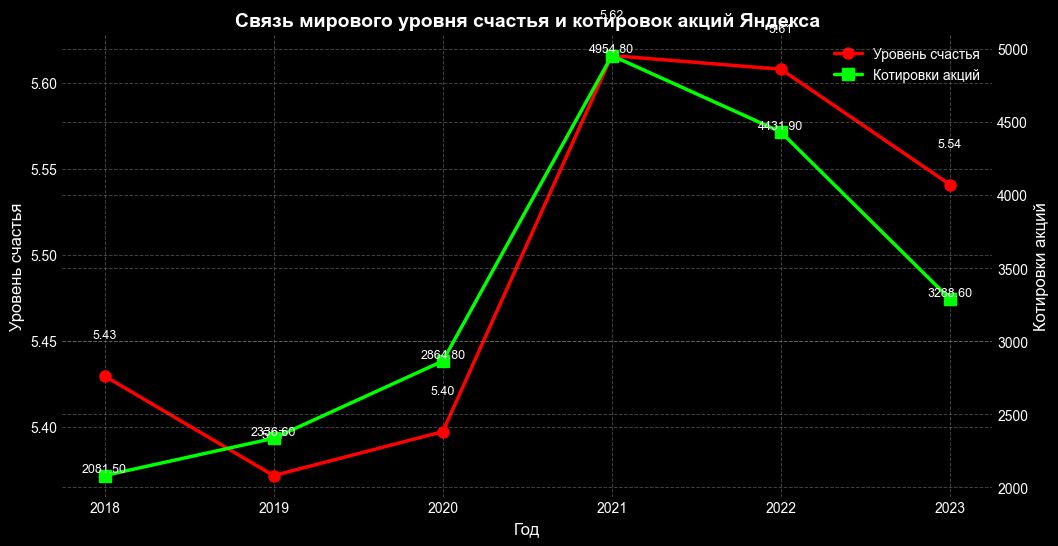

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

df2['Year'] = pd.to_datetime(df2['date']).dt.year
df2['Month'] = pd.to_datetime(df2['date']).dt.month
df_filtered = df[(df['Year'] >= 2018) & (df['Year'] <= 2023)]
df2_filtered = df2[(df2['Year'] >= 2018) & (df2['Year'] <= 2023)]
happiness_yearly = df_filtered.groupby('Year')['Happiness_Score'].mean().reset_index()
df2_midyear = df2_filtered[df2_filtered['Month'] == 6]
high_yearly = df2_midyear.groupby('Year')['high'].first().reset_index()
if 2023 not in high_yearly['Year'].values:
    df2_2023 = df2_filtered[df2_filtered['Year'] == 2023]
    if not df2_2023.empty:
        high_2023 = df2_2023['high'].iloc[0]
        high_yearly = pd.concat([high_yearly, pd.DataFrame({'Year': [2023], 'high': [high_2023]})], ignore_index=True)

high_yearly.loc[high_yearly['Year'] == 2022, 'high'] = high_yearly.loc[high_yearly['Year'] == 2022, 'high'] * 2.75

high_yearly.loc[high_yearly['Year'] == 2023, 'high'] = high_yearly.loc[high_yearly['Year'] == 2023, 'high'] * 1.8

merged_data = pd.merge(happiness_yearly, high_yearly, on='Year', how='outer')
merged_data = merged_data.sort_values('Year')
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('black')
ax1.set_facecolor('black')
color1 = '#FF0000'
ax1.set_xlabel('Год', fontsize=12, color='white')
ax1.set_ylabel('Уровень счастья', fontsize=12, color='white')
ax1.plot(merged_data['Year'], merged_data['Happiness_Score'],
         marker='o', linewidth=2.5, markersize=8, color=color1, label='Уровень счастья')
ax1.tick_params(axis='y', labelcolor='white')
ax1.tick_params(axis='x', colors='white')
color2 = '#00FF00'
ax2 = ax1.twinx()
ax2.set_ylabel('Котировки акций', fontsize=12, color='white')
ax2.plot(merged_data['Year'], merged_data['high'],
         marker='s', linewidth=2.5, markersize=8, color=color2, label='Котировки акций')
ax2.tick_params(axis='y', labelcolor='white')
for x, y in zip(merged_data['Year'], merged_data['Happiness_Score']):
    if pd.notna(y):
        ax1.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=9, color='white')

for x, y in zip(merged_data['Year'], merged_data['high']):
    if pd.notna(y):
        ax2.text(x, y + 0.02, f'{y:.2f}', ha='center', va='bottom', fontsize=9, color='white')

plt.title('Связь мирового уровня счастья и котировок акций Яндекса',
          fontsize=14, fontweight='bold', color='white')
ax1.grid(True, alpha=0.5, color='gray', linestyle='--', linewidth=0.7)
ax2.grid(True, alpha=0.5, color='gray', linestyle='--', linewidth=0.7)
ax1.set_xticks(merged_data['Year'])
ax1.set_xticklabels(merged_data['Year'], color='white')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', facecolor='black', edgecolor='white', labelcolor='white')

plt.show()
